In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('ushape.csv', header = None)
df.columns = ['X', 'Y', 'Class']

df['X'] = df['X'].round(4)
df['Y'] = df['Y'].round(4)

df.to_csv('ushape_final.csv', index = False)

In [3]:
df.head()

,X,Y,Class
0,0.0316,0.9870,0.0
1,2.1151,-0.0462,1.0
2,0.8825,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8295,-0.5393,1.0


In [4]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

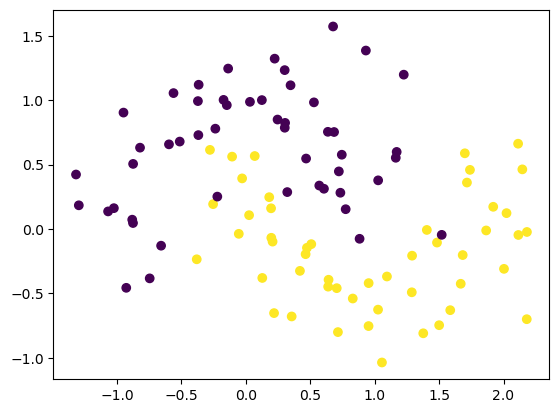

In [5]:
plt.scatter(X[:, 0], X[:, 1], c = y)

In [6]:
clf = LogisticRegression()
clf.fit(X, y)

LogisticRegression()

<Axes: >

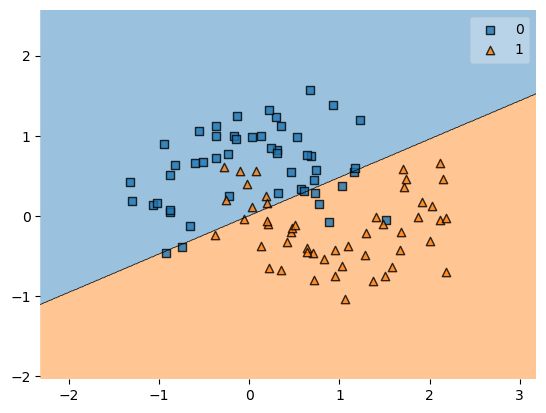

In [8]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf)

In [10]:
np.mean(cross_val_score(clf, X, y, scoring = 'accuracy', cv = 10))

np.float64(0.8300000000000001)

In [12]:
poly = PolynomialFeatures(degree = 3, include_bias = False)
X_trf = poly.fit_transform(X)

In [14]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1 ,X_trf, y, scoring = 'accuracy', cv = 10))

np.float64(0.9)

In [18]:
print(X.shape)
X_trf.shape

(100, 2)


(100, 9)

In [19]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

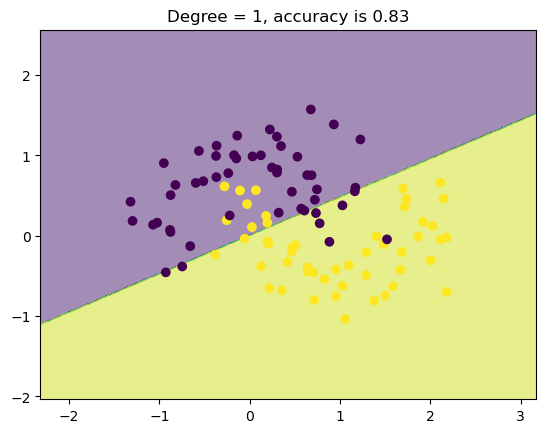

In [20]:
plot_decision_boundary(X, y)

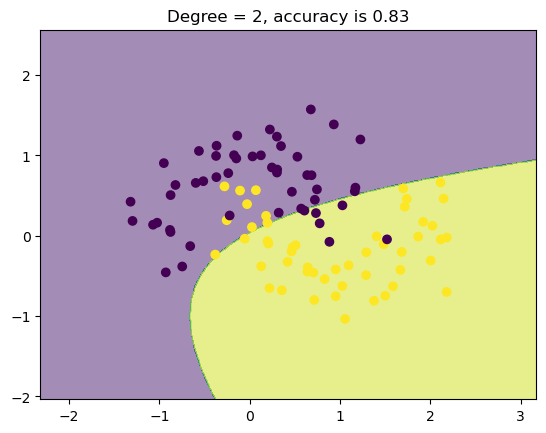

In [22]:
plot_decision_boundary(X, y, degree = 2)

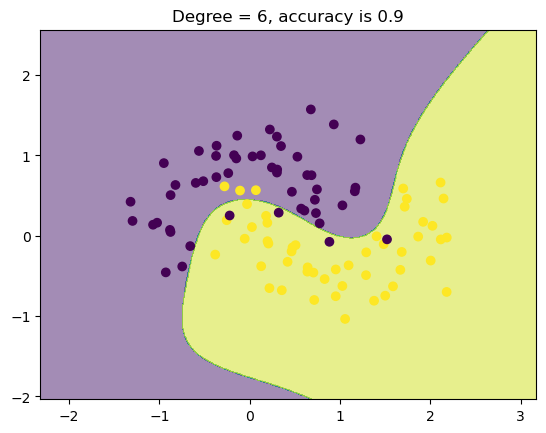

In [29]:
plot_decision_boundary(X, y, degree = 6)